In [3]:
import cv2
import numpy as np
import pandas as pd
import os
import csv
import joblib
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn import preprocessing
from skimage.filters import sobel
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import shannon_entropy
#Decision Tree Classifier
from sklearn.metrics import accuracy_score
import joblib
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import sklearn.metrics as metrics
import warnings
warnings.filterwarnings('ignore')

In [4]:
import cv2
import numpy as np

# Load the image
img = cv2.imread(r"C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\preprocessed\classroom\29.jpg")

# Find the keypoints using the FAST detector
fast = cv2.FastFeatureDetector_create()
kp = fast.detect(img,None)

# Select the first keypoint and extract the feature vector
kp_idx = 0
kp_coords = np.round(kp[kp_idx].pt).astype(int)
feature_vector = feature_vector[kp_idx]

# Define the size of the zoomed-in region
zoom_size = 50

# Extract the zoomed-in region of the image
zoom = img[kp_coords[1]-zoom_size//2:kp_coords[1]+zoom_size//2,
           kp_coords[0]-zoom_size//2:kp_coords[0]+zoom_size//2]

# Print the feature vector
print("Feature vector: ", feature_vector)

# Draw a circle around the keypoint on the original image
cv2.circle(img, tuple(kp_coords), 5, (0,0,255), -1)

# Display the zoomed-in region with the feature vector printed on it
cv2.putText(zoom, "Feature vector: " + str(feature_vector), (10,20),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
cv2.imshow("Zoomed-in region", zoom)

# Display the original image with the circle around the keypoint
cv2.imshow("Original image", img)

cv2.waitKey(0)
cv2.destroyAllWindows()


NameError: name 'feature_vector' is not defined

In [ ]:
from PIL import Image

# Define the input image file path
input_file_path = "/path/to/input_image.jpg"

# Define the output file path
output_file_path = "/path/to/resized_image.jpg"

# Define the desired output size
output_size = (240, 240)

# Open the input image file
input_image = Image.open(input_file_path)

# Resize the input image to the output size
resized_image = input_image.resize(output_size)

# Save the resized image to the output file path
resized_image.save(output_file_path)


In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load the feature data from the CSV file
feature_data = pd.read_csv("p1.csv")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(feature_data.drop("label", axis=1), feature_data["label"], test_size=0.2, random_state=42)

# Train an SVM classifier on the training data
svm_classifier = SVC(kernel="linear", C=1.0)
svm_classifier.fit(X_train, y_train)

# Test the classifier on the testing data
y_pred = svm_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)


Accuracy:  0.555


# star+brief+knn

In [30]:
import cv2
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Set the STAR and BRIEF parameters
star_params = dict(maxSize=16, responseThreshold=30, lineThresholdProjected=10, lineThresholdBinarized=8, suppressNonmaxSize=5)
brief_params = dict(bytes=32, use_orientation=False)

# Initialize the STAR detector and BRIEF extractor
star_detector = cv2.xfeatures2d.StarDetector_create(**star_params)
brief_extractor = cv2.xfeatures2d.BriefDescriptorExtractor_create(**brief_params)

# Loop over the images in the dataset
image_dir = r"C:\Users\Madhuri-Amit\Desktop\p1"
descriptors_list = []
labels_list = []
for class_name in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, class_name)
    for image_filename in os.listdir(class_dir):
        # Load the image and convert it to grayscale
        image_path = os.path.join(class_dir, image_filename)
        image = cv2.imread(image_path)
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect keypoints with the STAR detector
        keypoints = star_detector.detect(gray_image, None)

        # Compute BRIEF descriptors for the keypoints
        keypoints, descriptors = brief_extractor.compute(gray_image, keypoints)

        # Append the descriptors to the list
        if descriptors is not None:
            descriptors_list.append(np.mean(descriptors, axis=0))

            # Append the class label to the list
            labels_list.append(class_name)

# Convert the descriptor list and label list to Pandas dataframes
descriptors_df = pd.DataFrame(np.vstack(descriptors_list))
labels_df = pd.DataFrame({"label": labels_list})

# Concatenate the descriptor and label dataframes
combined_df = pd.concat([descriptors_df, labels_df], axis=1)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    combined_df.iloc[:, :-1], combined_df.iloc[:, -1], test_size=0.2, random_state=42)

# Train a KNN classifier on the training data
k = 10
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Evaluate the accuracy of the classifier on the testing data
accuracy = knn.score(X_test, y_test)
print(f"Accuracy: {accuracy}")


Accuracy: 0.535


# star+brief+svm

In [31]:
import cv2
import numpy as np
import os
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Set the STAR and BRIEF parameters
star_params = dict(maxSize=30, responseThreshold=30, lineThresholdProjected=10, lineThresholdBinarized=8, suppressNonmaxSize=5)
brief_params = dict(bytes=32, use_orientation=False)

# Initialize the STAR detector and BRIEF extractor
star_detector = cv2.xfeatures2d.StarDetector_create(**star_params)
brief_extractor = cv2.xfeatures2d.BriefDescriptorExtractor_create(**brief_params)

# Loop over the images in the dataset
image_dir = r"C:\Users\Madhuri-Amit\Desktop\p1"
descriptors_list = []
labels_list = []
for class_name in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, class_name)
    for image_filename in os.listdir(class_dir):
        # Load the image and convert it to grayscale
        image_path = os.path.join(class_dir, image_filename)
        image = cv2.imread(image_path)
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect keypoints with the STAR detector
        keypoints = star_detector.detect(gray_image, None)

        # Compute BRIEF descriptors for the keypoints
        keypoints, descriptors = brief_extractor.compute(gray_image, keypoints)

        # Append the descriptors to the list
        if descriptors is not None:
            descriptors_list.append(np.mean(descriptors, axis=0))

            # Append the class label to the list
            labels_list.append(class_name)

# Convert the descriptor list and label list to Pandas dataframes
descriptors_df = pd.DataFrame(np.vstack(descriptors_list))
labels_df = pd.DataFrame({"label": labels_list})

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(descriptors_df, labels_df, test_size=0.2, random_state=42)

# Initialize the SVM classifier
svm_classifier = SVC()

# Train the SVM classifier
svm_classifier.fit(X_train, y_train.values.ravel())

# Predict the class labels for the test set
y_pred = svm_classifier.predict(X_test)

# Calculate the accuracy of the SVM classifier
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)


Accuracy:  0.61


In [32]:
import cv2
import numpy as np
import os
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Set the STAR and BRIEF parameters
star_params = dict(maxSize=50, responseThreshold=30, lineThresholdProjected=10,
                   lineThresholdBinarized=8, suppressNonmaxSize=5)
brief_params = dict(bytes=32, use_orientation=False)

# Initialize the STAR detector and BRIEF extractor
star_detector = cv2.xfeatures2d.StarDetector_create(**star_params)
brief_extractor = cv2.xfeatures2d.BriefDescriptorExtractor_create(**brief_params)

# Loop over the images in the dataset
image_dir = r"C:\Users\Madhuri-Amit\Desktop\p1"
descriptors_list = []
labels_list = []
for class_name in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, class_name)
    for image_filename in os.listdir(class_dir):
        # Load the image and convert it to grayscale
        image_path = os.path.join(class_dir, image_filename)
        image = cv2.imread(image_path)
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect keypoints with the STAR detector
        keypoints = star_detector.detect(gray_image, None)

        # Compute BRIEF descriptors for the keypoints
        keypoints, descriptors = brief_extractor.compute(gray_image, keypoints)

        # Append the descriptors to the list
        if descriptors is not None:
            descriptors_list.append(np.mean(descriptors, axis=0))

            # Append the class label to the list
            labels_list.append(class_name)

# Convert the descriptor list and label list to Pandas dataframes
descriptors_df = pd.DataFrame(np.vstack(descriptors_list))
labels_df = pd.DataFrame({"label": labels_list})

# Concatenate the descriptor and label dataframes and split into training and testing sets
combined_df = pd.concat([descriptors_df, labels_df], axis=1)
X_train, X_test, y_train, y_test = train_test_split(combined_df.iloc[:, :-1], combined_df.iloc[:, -1],
                                                    test_size=0.2, random_state=42)

# Train a linear SVM classifier
svm_classifier = SVC(kernel='linear', C=1, random_state=42)
svm_classifier.fit(X_train, y_train)

# Predict the labels for the test set and calculate the accuracy
y_pred = svm_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.27225130890052357


# fast+brief+svm

In [34]:
import cv2
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Set the FAST and BRIEF parameters
fast_params = dict(threshold=20, nonmaxSuppression=True)
brief_params = dict(bytes=32, use_orientation=False)

# Initialize the FAST detector and BRIEF extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
brief_extractor = cv2.xfeatures2d.BriefDescriptorExtractor_create(**brief_params)

# Loop over the images in the dataset
image_dir = r"C:\Users\Madhuri-Amit\Desktop\aug2"
descriptors_list = []
labels_list = []
for class_name in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, class_name)
    for image_filename in os.listdir(class_dir):
        # Load the image and convert it to grayscale
        image_path = os.path.join(class_dir, image_filename)
        image = cv2.imread(image_path)
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect keypoints with the FAST detector
        keypoints = fast_detector.detect(gray_image, None)

        # Compute BRIEF descriptors for the keypoints
        keypoints, descriptors = brief_extractor.compute(gray_image, keypoints)

        # Append the descriptors to the list
        if descriptors is not None:
            descriptors_list.append(np.mean(descriptors, axis=0))

            # Append the class label to the list
            labels_list.append(class_name)

# Convert the descriptor list and label list to Pandas dataframes
descriptors_df = pd.DataFrame(np.vstack(descriptors_list))
labels_df = pd.DataFrame({"label": labels_list})

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(descriptors_df, labels_df, test_size=0.2, random_state=42)

# Train SVM classifier
svm = SVC(kernel='rbf', C=10, gamma=0.001)
svm.fit(X_train, y_train.values.ravel())

# Predict on test set and calculate accuracy
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.8445378151260504


# fast+freak+svm

In [36]:
import cv2
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Set the FAST and FREAK parameters
fast_params = dict(threshold=30, nonmaxSuppression=True)
freak_params = dict()

# Initialize the FAST detector and FREAK extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
freak_extractor = cv2.xfeatures2d.FREAK_create(**freak_params)

# Loop over the images in the dataset
image_dir = r"C:\Users\Madhuri-Amit\Desktop\p1"
descriptors_list = []
labels_list = []
for class_name in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, class_name)
    for image_filename in os.listdir(class_dir):
        # Load the image and convert it to grayscale
        image_path = os.path.join(class_dir, image_filename)
        image = cv2.imread(image_path)
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect keypoints with the FAST detector
        keypoints = fast_detector.detect(gray_image, None)

        # Compute FREAK descriptors for the keypoints
        keypoints, descriptors = freak_extractor.compute(gray_image, keypoints)

        # Append the descriptors to the list
        if descriptors is not None:
            descriptors_list.append(np.mean(descriptors, axis=0))

            # Append the class label to the list
            labels_list.append(class_name)

# Convert the descriptor list and label list to Pandas dataframes
descriptors_df = pd.DataFrame(np.vstack(descriptors_list))
labels_df = pd.DataFrame({"label": labels_list})

# Concatenate the descriptor and label dataframes
combined_df = pd.concat([descriptors_df, labels_df], axis=1)

# Split the data into training and testing sets
train_df, test_df = train_test_split(combined_df, test_size=0.2, random_state=42)

# Train an SVM classifier on the training data
svm = SVC(kernel='rbf', C=10, gamma=0.001)
svm.fit(train_df.drop("label", axis=1), train_df["label"])

# Predict the labels of the test data using the trained classifier
predictions = svm.predict(test_df.drop("label", axis=1))

# Compute the accuracy of the classifier on the test data
accuracy = accuracy_score(test_df["label"], predictions)
print("Accuracy: ", accuracy)


Accuracy:  0.885


# fast+freak+more data

In [37]:
import cv2
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Set the FAST and FREAK parameters
fast_params = dict(threshold=30, nonmaxSuppression=True)
freak_params = dict()

# Initialize the FAST detector and FREAK extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
freak_extractor = cv2.xfeatures2d.FREAK_create(**freak_params)

# Loop over the images in the dataset
image_dir = r"C:\Users\Madhuri-Amit\Desktop\aug2"
descriptors_list = []
labels_list = []
for class_name in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, class_name)
    for image_filename in os.listdir(class_dir):
        # Load the image and convert it to grayscale
        image_path = os.path.join(class_dir, image_filename)
        image = cv2.imread(image_path)
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect keypoints with the FAST detector
        keypoints = fast_detector.detect(gray_image, None)

        # Compute FREAK descriptors for the keypoints
        keypoints, descriptors = freak_extractor.compute(gray_image, keypoints)

        # Append the descriptors to the list
        if descriptors is not None:
            descriptors_list.append(np.mean(descriptors, axis=0))

            # Append the class label to the list
            labels_list.append(class_name)

# Convert the descriptor list and label list to Pandas dataframes
descriptors_df = pd.DataFrame(np.vstack(descriptors_list))
labels_df = pd.DataFrame({"label": labels_list})

# Concatenate the descriptor and label dataframes
combined_df = pd.concat([descriptors_df, labels_df], axis=1)

# Split the data into training and testing sets
train_df, test_df = train_test_split(combined_df, test_size=0.2, random_state=42)

# Train an SVM classifier on the training data
svm = SVC(kernel='rbf', C=10, gamma=0.001)
svm.fit(train_df.drop("label", axis=1), train_df["label"])

# Predict the labels of the test data using the trained classifier
predictions = svm.predict(test_df.drop("label", axis=1))

# Compute the accuracy of the classifier on the test data
accuracy = accuracy_score(test_df["label"], predictions)
print("Accuracy: ", accuracy)


Accuracy:  0.9432773109243697


# sift+svm

In [39]:
import cv2
import numpy as np
import os
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Set the SIFT parameters
sift_params = dict(nfeatures=0, nOctaveLayers=3, contrastThreshold=0.04, edgeThreshold=10, sigma=1.6)

# Initialize the SIFT detector and descriptor extractor
sift_detector = cv2.xfeatures2d.SIFT_create(**sift_params)

# Loop over the images in the dataset
image_dir = r"C:\Users\Madhuri-Amit\Desktop\p1"
descriptors_list = []
labels_list = []
for class_name in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, class_name)
    for image_filename in os.listdir(class_dir):
        # Load the image and convert it to grayscale
        image_path = os.path.join(class_dir, image_filename)
        image = cv2.imread(image_path)
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect keypoints with the SIFT detector
        keypoints = sift_detector.detect(gray_image, None)

        # Compute SIFT descriptors for the keypoints
        keypoints, descriptors = sift_detector.compute(gray_image, keypoints)

        # Append the descriptors to the list
        if descriptors is not None:
            descriptors_list.append(np.mean(descriptors, axis=0))

            # Append the class label to the list
            labels_list.append(class_name)

# Convert the descriptor list and label list to Pandas dataframes
descriptors_df = pd.DataFrame(np.vstack(descriptors_list))
labels_df = pd.DataFrame({"label": labels_list})

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(descriptors_df, labels_df, test_size=0.2)

# Train the SVM classifier
svm = SVC(kernel='rbf', C=10, gamma=0.001)
svm.fit(X_train, y_train.values.ravel())

# Make predictions on the testing set
y_pred = svm.predict(X_test)

# Calculate the accuracy of the classifier
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)


Accuracy:  0.995


In [40]:
import cv2
import numpy as np
import os
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Set the ORB parameters
orb_params = dict(nfeatures=1000, scaleFactor=1.2, nlevels=8)

# Initialize the ORB detector and descriptor extractor
orb = cv2.ORB_create(**orb_params)

# Loop over the images in the dataset
image_dir =  r"C:\Users\Madhuri-Amit\Desktop\p1"
descriptors_list = []
labels_list = []
for class_name in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, class_name)
    for image_filename in os.listdir(class_dir):
        # Load the image and convert it to grayscale
        image_path = os.path.join(class_dir, image_filename)
        image = cv2.imread(image_path)
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect keypoints with the ORB detector
        keypoints = orb.detect(gray_image, None)

        # Compute ORB descriptors for the keypoints
        keypoints, descriptors = orb.compute(gray_image, keypoints)

        # Append the descriptors to the list
        if descriptors is not None:
            descriptors_list.append(np.mean(descriptors, axis=0))

            # Append the class label to the list
            labels_list.append(class_name)

# Convert the descriptor list and label list to Pandas dataframes
descriptors_df = pd.DataFrame(np.vstack(descriptors_list))
labels_df = pd.DataFrame({"label": labels_list})

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(descriptors_df, labels_df, test_size=0.2, random_state=42)

# Initialize the SVM classifier
svm = SVC(kernel='linear', C=1.0, probability=True)

# Fit the SVM classifier to the training data
svm.fit(X_train, y_train.values.ravel())

# Predict the class labels of the test data
y_pred = svm.predict(X_test)

# Compute the accuracy of the classifier
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy*100))


Accuracy: 77.00%


# breif+svm

In [42]:
import cv2
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Set the BRISK parameters
brisk_params = dict(thresh=30, octaves=3)

# Initialize the BRISK detector and extractor
brisk_detector = cv2.BRISK_create(**brisk_params)
brisk_extractor = cv2.BRISK_create(**brisk_params)

# Loop over the images in the dataset
image_dir = r"C:\Users\Madhuri-Amit\Desktop\p1"
descriptors_list = []
labels_list = []
for class_name in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, class_name)
    for image_filename in os.listdir(class_dir):
        # Load the image and convert it to grayscale
        image_path = os.path.join(class_dir, image_filename)
        image = cv2.imread(image_path)
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect keypoints with the BRISK detector
        keypoints = brisk_detector.detect(gray_image, None)

        # Compute BRISK descriptors for the keypoints
        keypoints, descriptors = brisk_extractor.compute(gray_image, keypoints)

        # Append the descriptors to the list
        if descriptors is not None:
            descriptors_list.append(np.mean(descriptors, axis=0))

            # Append the class label to the list
            labels_list.append(class_name)

# Convert the descriptor list and label list to Pandas dataframes
descriptors_df = pd.DataFrame(np.vstack(descriptors_list))
labels_df = pd.DataFrame({"label": labels_list})

# Concatenate the descriptor and label dataframes and split into train/test sets
combined_df = pd.concat([descriptors_df, labels_df], axis=1)
train_df, test_df = train_test_split(combined_df, test_size=0.2, random_state=42)

# Train the SVM classifier
svm = SVC(kernel='linear', C=1)
svm.fit(train_df.drop('label', axis=1), train_df['label'])

# Evaluate the SVM classifier on the test set
accuracy = svm.score(test_df.drop('label', axis=1), test_df['label'])
print("Accuracy: {:.2f}%".format(accuracy * 100))


Accuracy: 86.50%


# freak+svm

In [45]:
import cv2
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Set the FREAK parameters
freak_params = dict()

# Initialize the FREAK extractor
freak_extractor = cv2.xfeatures2d.FREAK_create()

# Loop over the images in the dataset
image_dir = r"C:\Users\Madhuri-Amit\Desktop\p1"
descriptors_list = []
labels_list = []
for class_name in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, class_name)
    for image_filename in os.listdir(class_dir):
        # Load the image and convert it to grayscale
        image_path = os.path.join(class_dir, image_filename)
        image = cv2.imread(image_path)
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect keypoints with the STAR detector
        keypoints = cv2.xfeatures2d.StarDetector_create().detect(gray_image)

        # Compute FREAK descriptors for the keypoints
        _, descriptors = freak_extractor.compute(gray_image, keypoints)

        # Append the descriptors to the list
        if descriptors is not None:
            descriptors_list.append(np.mean(descriptors, axis=0))

            # Append the class label to the list
            labels_list.append(class_name)

# Convert the descriptor list and label list to Pandas dataframes
descriptors_df = pd.DataFrame(np.vstack(descriptors_list))
labels_df = pd.DataFrame({"label": labels_list})

# Concatenate the descriptor and label dataframes and split into train/test sets
combined_df = pd.concat([descriptors_df, labels_df], axis=1)
train_df, test_df = train_test_split(combined_df, test_size=0.2, stratify=labels_df)

# Train the SVM classifier
svm = SVC(kernel='rbf', C=10, gamma=0.001)
svm.fit(train_df.iloc[:,:-1], train_df.iloc[:,-1])

# Evaluate the model on the test set
predictions = svm.predict(test_df.iloc[:,:-1])
accuracy = accuracy_score(test_df.iloc[:,-1], predictions)
print("Accuracy: {:.2f}%".format(accuracy * 100))


Accuracy: 52.50%


# fast+freak+random forest

In [46]:
import cv2
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Set the FAST and FREAK parameters
fast_params = dict(threshold=30, nonmaxSuppression=True)
freak_params = dict()

# Initialize the FAST detector and FREAK extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
freak_extractor = cv2.xfeatures2d.FREAK_create(**freak_params)

# Loop over the images in the dataset
image_dir = r"C:\Users\Madhuri-Amit\Desktop\p1"
descriptors_list = []
labels_list = []
for class_name in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, class_name)
    for image_filename in os.listdir(class_dir):
        # Load the image and convert it to grayscale
        image_path = os.path.join(class_dir, image_filename)
        image = cv2.imread(image_path)
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect keypoints with the FAST detector
        keypoints = fast_detector.detect(gray_image, None)

        # Compute FREAK descriptors for the keypoints
        keypoints, descriptors = freak_extractor.compute(gray_image, keypoints)

        # Append the descriptors to the list
        if descriptors is not None:
            descriptors_list.append(np.mean(descriptors, axis=0))

            # Append the class label to the list
            labels_list.append(class_name)

# Convert the descriptor list and label list to Pandas dataframes
descriptors_df = pd.DataFrame(np.vstack(descriptors_list))
labels_df = pd.DataFrame({"label": labels_list})

# Concatenate the descriptor and label dataframes
combined_df = pd.concat([descriptors_df, labels_df], axis=1)

# Split the data into training and testing sets
train_df, test_df = train_test_split(combined_df, test_size=0.2, random_state=42)

# Train a Random Forest classifier on the training data
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(train_df.drop("label", axis=1), train_df["label"])

# Predict the labels of the test data using the trained classifier
predictions = rf.predict(test_df.drop("label", axis=1))

# Compute the accuracy of the classifier on the test data
accuracy = accuracy_score(test_df["label"], predictions)
print("Accuracy: ", accuracy)


Accuracy:  0.87


In [47]:
import cv2
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Set the FAST and FREAK parameters
fast_params = dict(threshold=30, nonmaxSuppression=True)
freak_params = dict()

# Initialize the FAST detector and FREAK extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
freak_extractor = cv2.xfeatures2d.FREAK_create(**freak_params)

# Loop over the images in the dataset
image_dir = r"C:\Users\Madhuri-Amit\Desktop\aug2"
descriptors_list = []
labels_list = []
for class_name in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, class_name)
    for image_filename in os.listdir(class_dir):
        # Load the image and convert it to grayscale
        image_path = os.path.join(class_dir, image_filename)
        image = cv2.imread(image_path)
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect keypoints with the FAST detector
        keypoints = fast_detector.detect(gray_image, None)

        # Compute FREAK descriptors for the keypoints
        keypoints, descriptors = freak_extractor.compute(gray_image, keypoints)

        # Append the descriptors to the list
        if descriptors is not None:
            descriptors_list.append(np.mean(descriptors, axis=0))

            # Append the class label to the list
            labels_list.append(class_name)

# Convert the descriptor list and label list to Pandas dataframes
descriptors_df = pd.DataFrame(np.vstack(descriptors_list))
labels_df = pd.DataFrame({"label": labels_list})

# Concatenate the descriptor and label dataframes
combined_df = pd.concat([descriptors_df, labels_df], axis=1)

# Split the data into training and testing sets
train_df, test_df = train_test_split(combined_df, test_size=0.2, random_state=42)

# Train a Random Forest classifier on the training data
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(train_df.drop("label", axis=1), train_df["label"])

# Predict the labels of the test data using the trained classifier
predictions = rf.predict(test_df.drop("label", axis=1))

# Compute the accuracy of the classifier on the test data
accuracy = accuracy_score(test_df["label"], predictions)
print("Accuracy: ", accuracy)


Accuracy:  0.9096638655462185


# fast+freak+knn

In [48]:
import cv2
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Set the FAST and FREAK parameters
fast_params = dict(threshold=30, nonmaxSuppression=True)
freak_params = dict()

# Initialize the FAST detector and FREAK extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
freak_extractor = cv2.xfeatures2d.FREAK_create(**freak_params)

# Loop over the images in the dataset
image_dir = r"C:\Users\Madhuri-Amit\Desktop\p1"
descriptors_list = []
labels_list = []
for class_name in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, class_name)
    for image_filename in os.listdir(class_dir):
        # Load the image and convert it to grayscale
        image_path = os.path.join(class_dir, image_filename)
        image = cv2.imread(image_path)
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect keypoints with the FAST detector
        keypoints = fast_detector.detect(gray_image, None)

        # Compute FREAK descriptors for the keypoints
        keypoints, descriptors = freak_extractor.compute(gray_image, keypoints)

        # Append the descriptors to the list
        if descriptors is not None:
            descriptors_list.append(np.mean(descriptors, axis=0))

            # Append the class label to the list
            labels_list.append(class_name)

# Convert the descriptor list and label list to Pandas dataframes
descriptors_df = pd.DataFrame(np.vstack(descriptors_list))
labels_df = pd.DataFrame({"label": labels_list})

# Concatenate the descriptor and label dataframes
combined_df = pd.concat([descriptors_df, labels_df], axis=1)

# Split the data into training and testing sets
train_df, test_df = train_test_split(combined_df, test_size=0.2, random_state=42)

# Train a kNN classifier on the training data
k = 5 # number of neighbors
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(train_df.drop("label", axis=1), train_df["label"])

# Predict the labels of the test data using the trained classifier
predictions = knn.predict(test_df.drop("label", axis=1))

# Compute the accuracy of the classifier on the test data
accuracy = accuracy_score(test_df["label"], predictions)
print("Accuracy: ", accuracy)


Accuracy:  0.895


In [49]:
import cv2
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Set the FAST and FREAK parameters
fast_params = dict(threshold=30, nonmaxSuppression=True)
freak_params = dict()

# Initialize the FAST detector and FREAK extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
freak_extractor = cv2.xfeatures2d.FREAK_create(**freak_params)

# Loop over the images in the dataset
image_dir = r"C:\Users\Madhuri-Amit\Desktop\aug2"
descriptors_list = []
labels_list = []
for class_name in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, class_name)
    for image_filename in os.listdir(class_dir):
        # Load the image and convert it to grayscale
        image_path = os.path.join(class_dir, image_filename)
        image = cv2.imread(image_path)
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect keypoints with the FAST detector
        keypoints = fast_detector.detect(gray_image, None)

        # Compute FREAK descriptors for the keypoints
        keypoints, descriptors = freak_extractor.compute(gray_image, keypoints)

        # Append the descriptors to the list
        if descriptors is not None:
            descriptors_list.append(np.mean(descriptors, axis=0))

            # Append the class label to the list
            labels_list.append(class_name)

# Convert the descriptor list and label list to Pandas dataframes
descriptors_df = pd.DataFrame(np.vstack(descriptors_list))
labels_df = pd.DataFrame({"label": labels_list})

# Concatenate the descriptor and label dataframes
combined_df = pd.concat([descriptors_df, labels_df], axis=1)

# Split the data into training and testing sets
train_df, test_df = train_test_split(combined_df, test_size=0.2, random_state=42)

# Train a kNN classifier on the training data
k = 5 # number of neighbors
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(train_df.drop("label", axis=1), train_df["label"])

# Predict the labels of the test data using the trained classifier
predictions = knn.predict(test_df.drop("label", axis=1))

# Compute the accuracy of the classifier on the test data
accuracy = accuracy_score(test_df["label"], predictions)
print("Accuracy: ", accuracy)


Accuracy:  0.9117647058823529


# fast+freak+decision tree

In [51]:
import cv2
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Set the FAST and FREAK parameters
fast_params = dict(threshold=30, nonmaxSuppression=True)
freak_params = dict()

# Initialize the FAST detector and FREAK extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
freak_extractor = cv2.xfeatures2d.FREAK_create(**freak_params)

# Loop over the images in the dataset
image_dir = r"C:\Users\Madhuri-Amit\Desktop\p1"
descriptors_list = []
labels_list = []
for class_name in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, class_name)
    for image_filename in os.listdir(class_dir):
        # Load the image and convert it to grayscale
        image_path = os.path.join(class_dir, image_filename)
        image = cv2.imread(image_path)
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect keypoints with the FAST detector
        keypoints = fast_detector.detect(gray_image, None)

        # Compute FREAK descriptors for the keypoints
        keypoints, descriptors = freak_extractor.compute(gray_image, keypoints)

        # Append the descriptors to the list
        if descriptors is not None:
            descriptors_list.append(np.mean(descriptors, axis=0))

            # Append the class label to the list
            labels_list.append(class_name)

# Convert the descriptor list and label list to Pandas dataframes
descriptors_df = pd.DataFrame(np.vstack(descriptors_list))
labels_df = pd.DataFrame({"label": labels_list})

# Concatenate the descriptor and label dataframes
combined_df = pd.concat([descriptors_df, labels_df], axis=1)

# Split the data into training and testing sets
train_df, test_df = train_test_split(combined_df, test_size=0.2, random_state=42)

# Train a Decision Tree classifier on the training data
dtc = DecisionTreeClassifier()
dtc.fit(train_df.drop("label", axis=1), train_df["label"])

# Predict the labels of the test data using the trained classifier
predictions = dtc.predict(test_df.drop("label", axis=1))

# Compute the accuracy of the classifier on the test data
accuracy = accuracy_score(test_df["label"], predictions)
print("Accuracy: ", accuracy)


Accuracy:  0.75


In [52]:
import cv2
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Set the FAST and FREAK parameters
fast_params = dict(threshold=30, nonmaxSuppression=True)
freak_params = dict()

# Initialize the FAST detector and FREAK extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
freak_extractor = cv2.xfeatures2d.FREAK_create(**freak_params)

# Loop over the images in the dataset
image_dir = r"C:\Users\Madhuri-Amit\Desktop\aug2"
descriptors_list = []
labels_list = []
for class_name in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, class_name)
    for image_filename in os.listdir(class_dir):
        # Load the image and convert it to grayscale
        image_path = os.path.join(class_dir, image_filename)
        image = cv2.imread(image_path)
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect keypoints with the FAST detector
        keypoints = fast_detector.detect(gray_image, None)

        # Compute FREAK descriptors for the keypoints
        keypoints, descriptors = freak_extractor.compute(gray_image, keypoints)

        # Append the descriptors to the list
        if descriptors is not None:
            descriptors_list.append(np.mean(descriptors, axis=0))

            # Append the class label to the list
            labels_list.append(class_name)

# Convert the descriptor list and label list to Pandas dataframes
descriptors_df = pd.DataFrame(np.vstack(descriptors_list))
labels_df = pd.DataFrame({"label": labels_list})

# Concatenate the descriptor and label dataframes
combined_df = pd.concat([descriptors_df, labels_df], axis=1)

# Split the data into training and testing sets
train_df, test_df = train_test_split(combined_df, test_size=0.2, random_state=42)

# Train a Decision Tree classifier on the training data
dtc = DecisionTreeClassifier()
dtc.fit(train_df.drop("label", axis=1), train_df["label"])

# Predict the labels of the test data using the trained classifier
predictions = dtc.predict(test_df.drop("label", axis=1))

# Compute the accuracy of the classifier on the test data
accuracy = accuracy_score(test_df["label"], predictions)
print("Accuracy: ", accuracy)


Accuracy:  0.7815126050420168


In [54]:
import cv2
import numpy as np
import pickle

import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Set the FAST and FREAK parameters
fast_params = dict(threshold=30, nonmaxSuppression=True)
freak_params = dict()

# Initialize the FAST detector and FREAK extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
freak_extractor = cv2.xfeatures2d.FREAK_create(**freak_params)

# Loop over the images in the dataset
image_dir = r"C:\Users\Madhuri-Amit\Desktop\aug2"
descriptors_list = []
labels_list = []
for class_name in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, class_name)
    for image_filename in os.listdir(class_dir):
        # Load the image and convert it to grayscale
        image_path = os.path.join(class_dir, image_filename)
        image = cv2.imread(image_path)
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect keypoints with the FAST detector
        keypoints = fast_detector.detect(gray_image, None)

        # Compute FREAK descriptors for the keypoints
        keypoints, descriptors = freak_extractor.compute(gray_image, keypoints)

        # Append the descriptors to the list
        if descriptors is not None:
            descriptors_list.append(np.mean(descriptors, axis=0))

            # Append the class label to the list
            labels_list.append(class_name)

# Convert the descriptor list and label list to Pandas dataframes
descriptors_df = pd.DataFrame(np.vstack(descriptors_list))
labels_df = pd.DataFrame({"label": labels_list})

# Concatenate the descriptor and label dataframes
combined_df = pd.concat([descriptors_df, labels_df], axis=1)
# Save the combined dataframe as a CSV file
combined_df.to_csv('freak.csv', index=False)


# Split the data into training and testing sets
train_df, test_df = train_test_split(combined_df, test_size=0.2, random_state=42)

# Train an SVM classifier on the training data
# Train an SVM classifier on the training data
svm = SVC(kernel='rbf', C=10, gamma=0.001)
svm.fit(train_df.drop("label", axis=1), train_df["label"])

# Save the trained SVM model to a file
filename = 'svm_model.sav'
pickle.dump(svm, open(filename, 'wb'))

# Predict the labels of the test data using the trained classifier
predictions = svm.predict(test_df.drop("label", axis=1))

# Compute the accuracy of the classifier on the test data
accuracy = accuracy_score(test_df["label"], predictions)
print("Accuracy: ", accuracy)



Accuracy:  0.9432773109243697


In [2]:
data1 = pd.read_csv(r"C:\Users\Madhuri-Amit\Downloads\freak.csv")

In [3]:
data1

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,label
0,115.205742,114.224880,158.483254,154.827751,114.626794,145.215311,134.631579,124.244019,140.770335,149.765550,...,96.095694,72.267943,190.000000,91.909091,175.387560,123.985646,110.358852,74.622010,215.009569,boatclub
1,100.330357,92.437500,119.589286,148.169643,116.125000,127.580357,114.294643,99.803571,106.767857,131.142857,...,99.098214,62.017857,164.883929,77.991071,161.625000,102.580357,103.428571,63.098214,205.803571,boatclub
2,100.929936,96.337580,132.885350,135.942675,109.980892,127.025478,117.490446,106.363057,124.745223,125.464968,...,101.566879,50.343949,183.605096,82.140127,166.783439,109.490446,110.369427,59.847134,212.140127,boatclub
3,97.356364,93.883636,133.214545,140.869091,124.094545,132.905455,114.610909,104.527273,104.214545,129.589091,...,89.574545,51.709091,169.996364,79.796364,156.116364,95.298182,97.952727,69.709091,198.090909,boatclub
4,96.989130,96.510870,132.108696,160.336957,107.326087,137.847826,122.152174,115.021739,100.489130,140.750000,...,77.760870,55.554348,179.021739,69.902174,165.956522,91.510870,90.793478,48.554348,218.663043,boatclub
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2374,103.553425,109.430137,137.742466,146.079452,110.758904,138.915068,118.819178,108.942466,121.249315,134.284932,...,88.493151,56.117808,188.454795,79.210959,161.232877,106.410959,116.252055,64.852055,205.353425,playground
2375,109.777778,131.287037,155.351852,169.166667,123.379630,156.046296,140.472222,121.250000,131.722222,153.972222,...,97.074074,65.120370,200.111111,96.740741,168.018519,122.083333,126.907407,75.435185,216.268519,playground
2376,95.634409,104.413978,146.994624,150.704301,100.188172,127.790323,112.473118,117.569892,137.989247,138.005376,...,84.032258,53.139785,195.430108,76.150538,163.338710,104.731183,103.661290,56.258065,209.376344,playground
2377,98.970414,104.804734,135.680473,164.278107,100.461538,136.982249,116.295858,107.674556,131.047337,138.023669,...,91.094675,51.130178,193.650888,82.621302,177.254438,113.828402,117.076923,61.917160,219.491124,playground


In [4]:
data1 = pd.read_csv(r"C:\Users\Madhuri-Amit\Downloads\freak1.csv")

In [5]:
data1 = data1.astype('uint8')

In [6]:
data1

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,label
0,115,114,158,154,114,145,134,124,140,149,...,96,72,190,91,175,123,110,74,215,0
1,100,92,119,148,116,127,114,99,106,131,...,99,62,164,77,161,102,103,63,205,0
2,100,96,132,135,109,127,117,106,124,125,...,101,50,183,82,166,109,110,59,212,0
3,97,93,133,140,124,132,114,104,104,129,...,89,51,169,79,156,95,97,69,198,0
4,96,96,132,160,107,137,122,115,100,140,...,77,55,179,69,165,91,90,48,218,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2374,103,109,137,146,110,138,118,108,121,134,...,88,56,188,79,161,106,116,64,205,4
2375,109,131,155,169,123,156,140,121,131,153,...,97,65,200,96,168,122,126,75,216,4
2376,95,104,146,150,100,127,112,117,137,138,...,84,53,195,76,163,104,103,56,209,4
2377,98,104,135,164,100,136,116,107,131,138,...,91,51,193,82,177,113,117,61,219,4


In [7]:
kmeans1 = KMeans(n_clusters=10)
kmeans1.fit(data1)

KMeans(n_clusters=10)

In [8]:
import os
from sklearn.cluster import KMeans
import joblib

directory = "./t/freak"
if not os.path.exists(directory):
    os.makedirs(directory)

In [9]:
kmeans5 = KMeans(n_clusters=10)
kmeans5.fit(data1)

joblib.dump(kmeans5, './t/freak/Kmeans_A')

['./t/freak/Kmeans_A']

In [10]:
data1.to_csv(r'C:\Users\Madhuri-Amit\Downloads\file4.csv', index=False)


In [16]:
df1 = pd.read_csv(r"C:\Users\Madhuri-Amit\Downloads\file4.csv",index_col=False)
X = df1.iloc[:, :-1]  # selects all rows (:) and all column but the last column (:-1) of the DataFrame df.
Y = df1.iloc[:, -1]    #  selects all rows (:) and the last column (-1) of the DataFrame df.

# train test split
x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size=0.8, random_state=5)

In [36]:
kmeans1 = KMeans(n_clusters=10, random_state=42)
kmeans1.fit(x_train1)

KMeans(n_clusters=10, random_state=42)

In [37]:
kmeans2 = KMeans(n_clusters=10, random_state=42)
kmeans2.fit(x_test1)

KMeans(n_clusters=10, random_state=42)

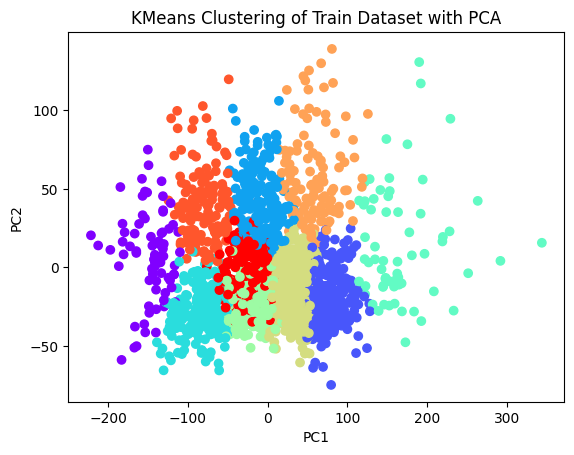

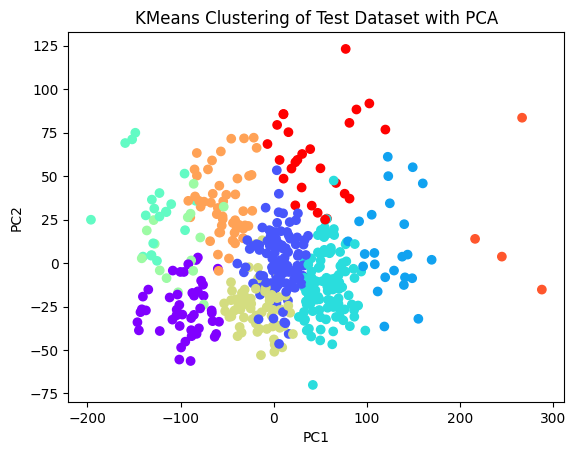

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Get the labels of the clusters
labels1 = kmeans1.labels_
labels2 = kmeans2.labels_

# Add the cluster labels as a new column to the dataset
x_train1['cluster'] = labels1
x_test1['cluster'] = labels2

# Perform PCA on the dataset with the added cluster labels as a column
pca = PCA(n_components=10)
x_train1_pca = pca.fit_transform(x_train1.iloc[:, :-1])
x_test1_pca = pca.fit_transform(x_test1.iloc[:, :-1])

# pca.transform(y)

# Visualize the data in 2D with the cluster labels for coloring
plt.scatter(x_train1_pca[:, 0], x_train1_pca[:, 1], c=labels1, cmap='rainbow')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clustering of Train Dataset with PCA')
plt.show()

plt.scatter(x_test1_pca[:, 0], x_test1_pca[:, 1], c=labels2, cmap='rainbow')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clustering of Test Dataset with PCA')
plt.show()

In [39]:
df = pd.read_csv(r"C:\Users\Madhuri-Amit\Downloads\freak1.csv")
X = df.iloc[:, :-1]  # selects all rows (:) and all but the last column (:-1) of the DataFrame df.
Y = df.iloc[:, -1]    #  selects all rows (:) and the last column (-1) of the DataFrame df.

# train test split
x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size=0.8, random_state=5)

In [40]:
X

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,115.205742,114.224880,158.483254,154.827751,114.626794,145.215311,134.631579,124.244019,140.770335,149.765550,...,145.148325,96.095694,72.267943,190.000000,91.909091,175.387560,123.985646,110.358852,74.622010,215.009569
1,100.330357,92.437500,119.589286,148.169643,116.125000,127.580357,114.294643,99.803571,106.767857,131.142857,...,143.839286,99.098214,62.017857,164.883929,77.991071,161.625000,102.580357,103.428571,63.098214,205.803571
2,100.929936,96.337580,132.885350,135.942675,109.980892,127.025478,117.490446,106.363057,124.745223,125.464968,...,146.127388,101.566879,50.343949,183.605096,82.140127,166.783439,109.490446,110.369427,59.847134,212.140127
3,97.356364,93.883636,133.214546,140.869091,124.094545,132.905454,114.610909,104.527273,104.214545,129.589091,...,136.989091,89.574545,51.709091,169.996364,79.796364,156.116364,95.298182,97.952727,69.709091,198.090909
4,96.989130,96.510870,132.108696,160.336957,107.326087,137.847826,122.152174,115.021739,100.489130,140.750000,...,142.250000,77.760870,55.554348,179.021739,69.902174,165.956522,91.510870,90.793478,48.554348,218.663043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2374,103.553425,109.430137,137.742466,146.079452,110.758904,138.915068,118.819178,108.942466,121.249315,134.284931,...,145.520548,88.493151,56.117808,188.454794,79.210959,161.232877,106.410959,116.252055,64.852055,205.353425
2375,109.777778,131.287037,155.351852,169.166667,123.379630,156.046296,140.472222,121.250000,131.722222,153.972222,...,158.490741,97.074074,65.120370,200.111111,96.740741,168.018518,122.083333,126.907407,75.435185,216.268518
2376,95.634409,104.413978,146.994624,150.704301,100.188172,127.790323,112.473118,117.569892,137.989247,138.005376,...,147.897850,84.032258,53.139785,195.430107,76.150538,163.338710,104.731183,103.661290,56.258065,209.376344
2377,98.970414,104.804734,135.680473,164.278107,100.461539,136.982248,116.295858,107.674556,131.047337,138.023669,...,144.431953,91.094675,51.130178,193.650888,82.621302,177.254438,113.828402,117.076923,61.917160,219.491124


In [41]:
Y

0       0
1       0
2       0
3       0
4       0
       ..
2374    4
2375    4
2376    4
2377    4
2378    4
Name: label, Length: 2379, dtype: int64

In [42]:
x_train

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
863,83.177632,109.868421,156.967105,157.296053,92.269737,157.414474,131.611842,103.861842,132.131579,161.480263,...,145.842105,79.585526,50.743421,193.993421,82.552632,176.236842,108.151316,125.960526,59.690789,219.565789
286,93.037037,83.192593,124.248148,123.518518,108.837037,121.888889,105.022222,99.477778,100.966667,116.125926,...,130.244444,96.300000,55.392593,161.907407,74.185185,159.403704,95.722222,96.466667,61.337037,194.122222
1419,103.519789,100.839050,138.448549,143.203166,116.187335,134.757256,115.831135,111.609499,122.211082,137.131926,...,139.126649,90.166227,57.224274,185.208443,82.229551,169.638522,106.704486,100.076517,63.168865,210.799472
1018,79.380814,92.619186,114.075581,126.523256,100.877907,127.470930,96.863372,92.142442,99.011628,123.293605,...,137.476744,82.450581,52.549419,175.438953,65.200581,152.976744,90.875000,98.311047,59.755814,200.936047
1538,104.438679,94.429245,132.872641,132.632076,108.688679,129.504717,113.405660,112.056604,127.995283,127.896226,...,135.250000,91.278302,55.721698,185.174528,76.608491,170.396226,99.051887,100.320755,67.301887,195.448113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032,100.260870,131.891304,148.152174,155.934783,103.847826,134.956522,136.869565,99.934783,126.500000,164.195652,...,154.043478,98.456522,49.152174,190.413043,94.130435,163.282609,100.608696,125.869565,66.130435,206.913043
2121,100.744868,108.800586,140.489736,145.073314,111.302053,135.486804,114.126100,104.577713,115.114369,134.105572,...,141.736070,90.111437,56.715543,179.126100,80.310850,161.049853,106.149560,109.436950,60.782991,201.117302
1424,76.018433,74.437788,131.359447,129.027650,92.041475,115.400922,88.442396,107.327189,127.327189,119.529954,...,144.746544,70.410138,40.165899,182.248848,64.248848,164.046083,87.589862,92.023041,54.188940,206.930876
1725,115.998344,126.668874,142.279801,144.726821,117.741722,143.572848,135.382450,122.649007,121.990066,153.988411,...,146.201987,97.048013,66.483444,197.697020,86.365894,164.268212,111.899007,111.109272,69.405629,201.619205


In [43]:
y_train

863     1
286     0
1419    2
1018    1
1538    2
       ..
1032    1
2121    4
1424    2
1725    3
2254    4
Name: label, Length: 1903, dtype: int64

In [44]:
x_test

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
1735,111.334059,120.479869,141.255713,142.334059,115.912949,140.964091,124.960827,112.291621,126.424374,138.874864,...,144.445049,94.704026,58.857454,185.520131,85.310120,165.289445,109.266594,110.306855,72.245919,204.195865
2295,105.595588,116.617647,160.316177,168.926471,115.301471,137.705882,130.242647,111.272059,163.286765,145.801471,...,152.036765,79.691176,56.250000,193.235294,90.610294,178.191177,123.669118,121.338235,65.889706,222.838235
936,86.035549,103.268934,121.489954,135.431221,100.119011,130.156105,112.965997,97.544049,108.166924,128.565688,...,142.119011,83.318393,54.989181,174.491499,74.761978,163.136012,99.285935,111.278207,66.986090,194.823802
602,96.684211,100.388158,135.835526,155.328947,104.618421,135.651316,122.848684,109.328947,116.901316,144.381579,...,141.927632,96.789474,59.842105,182.631579,78.710526,167.282895,104.703947,106.631579,60.539474,213.809211
1744,99.002874,106.399425,137.609195,137.343391,107.027299,136.181035,122.941092,113.660920,114.767241,139.754310,...,145.887931,86.367816,56.354885,182.287356,82.117816,163.142241,104.771552,104.232759,68.255747,198.905172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049,74.732143,111.339286,137.464286,162.357143,75.821429,148.107143,124.160714,90.910714,115.160714,133.017857,...,154.803571,80.196429,46.660714,185.607143,59.053571,173.142857,99.428571,118.767857,66.571429,222.053571
1367,104.374372,87.861809,138.625628,145.683417,119.231156,130.816583,114.665829,108.261307,113.532663,139.261306,...,139.741206,90.218593,53.180905,174.296482,71.844221,164.934673,98.140704,93.592965,54.889447,209.364322
1489,112.420290,116.060041,149.436853,152.677019,117.879917,140.060041,130.004141,111.728779,124.639752,148.422360,...,146.097308,98.583851,56.037267,191.668737,82.703934,171.718426,107.863354,112.563147,68.774327,209.931677
410,103.897561,97.497561,124.731707,142.765854,108.346341,133.053659,120.556098,111.141463,99.839024,143.117073,...,142.751219,96.526829,54.029268,177.570732,80.653659,160.863415,98.463415,98.936585,69.887805,195.278049


In [45]:
y_test

1735    3
2295    4
936     1
602     0
1744    3
       ..
1049    1
1367    2
1489    2
410     0
1435    2
Name: label, Length: 476, dtype: int64

In [17]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

train_X = sc.fit_transform(x_train)
test_X = sc.transform(x_test)

In [18]:
train_X

array([[-0.84931075,  0.42849551,  1.72628944, ...,  1.91050672,
        -0.57957953,  1.49509743],
       [-0.09504607, -1.13190052, -0.71204985, ..., -0.81236747,
        -0.27145274, -1.21458867],
       [ 0.65921861, -0.11164158,  0.35472359, ..., -0.43679862,
         0.03667405,  0.51961043],
       ...,
       [-1.37729603, -1.67203761, -0.17866313, ..., -1.18793632,
        -1.3498965 ,  0.08606066],
       [ 1.56433623,  1.44875446,  0.659516  , ...,  0.59601573,
         0.96105442, -0.45587656],
       [ 2.39402738,  4.3294856 ,  4.77421356, ...,  5.76008746,
         2.19356157,  2.1454221 ]])

In [19]:
test_X

array([[ 1.26263036,  1.08866306,  0.5833179 , ...,  0.50212352,
         1.4232446 , -0.13071423],
       [ 0.81007155,  0.84860214,  2.03108185, ...,  1.53493786,
         0.34480084,  1.82025976],
       [-0.62303135,  0.06840412, -0.94064416, ...,  0.59601573,
         0.49886423, -1.21458867],
       ...,
       [ 1.33805682,  0.84860214,  1.19290272, ...,  0.68990794,
         0.80699102,  0.41122299],
       [ 0.65921861, -0.29168727, -0.71204985, ..., -0.62458304,
         0.96105442, -1.10620123],
       [ 0.96092448,  0.42849551,  1.34529893, ...,  0.03266245,
        -0.11738934,  0.73638532]])

In [20]:
#Decision Tree Classifier
from sklearn.metrics import accuracy_score
import joblib
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import sklearn.metrics as metrics
#Assign model with Decision Tree classifier


model_dt = DecisionTreeClassifier(max_depth=6)

model_dt.fit(x_train, y_train)

joblib.dump(model_dt,"./t/freak/model_dt_A")

#predicting the traget variable using testing variables
y_pred1 = model_dt.predict(x_test)
#Results

print("Decision Tree Results")
print("Decision Tree Accuracy: ",accuracy_score(y_test, y_pred1)*100,"%")
print("Train Accuracy:",model_dt.score(x_train, y_train))
print("Test Accuracy:",model_dt.score(x_test, y_test))
print("Precision Score: ",metrics.precision_score(y_test, y_pred1, pos_label='positive', average='micro'))
print("Recall Score: ",metrics.recall_score(y_test, y_pred1, pos_label='positive', average='micro')) # true positive rate, Sensitivity
print("F2 Score: ",metrics.fbeta_score(y_test, y_pred1, pos_label='positive', average='micro', beta=2.0))
print("F1 Score: ",metrics.f1_score(y_test, y_pred1, pos_label='positive', average='micro'))
print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred1))

#print("ROC curve ",metrics.plot_roc_curve(model_dt,x_test, y_test))


Decision Tree Results
Decision Tree Accuracy:  74.57983193277312 %
Train Accuracy: 0.8644245927482922
Test Accuracy: 0.7457983193277311
Precision Score:  0.7457983193277311
Recall Score:  0.7457983193277311
F2 Score:  0.7457983193277311
F1 Score:  0.7457983193277311
Confusion Matrix: 
[[118   4   1   1   6]
 [  6  66   6  12   4]
 [ 10  10  66   6   2]
 [  0  16   4  74   1]
 [ 13   8   3   8  31]]


In [22]:
#KNN classifier
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors = 13)
model_knn.fit(x_train, y_train)


joblib.dump(model_knn,"./t/freak/modelA_knn")
y_pred3 = model_knn.predict(x_test)
print("KNN")
print("Train Accuracy:",model_knn.score(x_train, y_train))
print("Test Accuracy:",model_knn.score(x_test, y_test))
print("Precision Score: ",metrics.precision_score(y_test, y_pred3, pos_label='positive', average='micro'))
print("Recall Score: ",metrics.recall_score(y_test, y_pred3, pos_label='positive', average='micro'))
print("F1 Score: ",metrics.f1_score(y_test, y_pred3, pos_label='positive', average='micro'))
print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred3,))
#print("ROC curve ",metrics.plot_roc_curve(model_knn,x_test, y_test))

KNN
Train Accuracy: 0.8780872306883868
Test Accuracy: 0.8445378151260504
Precision Score:  0.8445378151260504
Recall Score:  0.8445378151260504
F1 Score:  0.8445378151260504
Confusion Matrix: 
[[129   0   1   0   0]
 [  4  76   2  10   2]
 [  3   1  79  10   1]
 [  0   1   4  90   0]
 [ 12   5   2  16  28]]


In [23]:
from sklearn.svm import SVC

model_svm = SVC(kernel='linear', C=1.0)
model_svm.fit(x_train, y_train)

joblib.dump(model_svm, "./t/freak/modelA_svm")

y_pred4 = model_svm.predict(x_test)
print("SVM")
print("Train Accuracy:", model_svm.score(x_train, y_train))
print("Test Accuracy:", model_svm.score(x_test, y_test))
print("Precision Score: ", metrics.precision_score(y_test, y_pred4, pos_label='positive', average='micro'))
print("Recall Score: ", metrics.recall_score(y_test, y_pred4, pos_label='positive', average='micro'))
print("F1 Score: ", metrics.f1_score(y_test, y_pred4, pos_label='positive', average='micro'))
print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred4))
#print("ROC curve ", metrics.plot_roc_curve(model_svm, x_test, y_test))


SVM
Train Accuracy: 0.9942196531791907
Test Accuracy: 0.8991596638655462
Precision Score:  0.8991596638655462
Recall Score:  0.8991596638655462
F1 Score:  0.8991596638655462
Confusion Matrix: 
[[122   1   5   0   2]
 [  3  83   3   4   1]
 [  3   3  85   3   0]
 [  0   4   4  87   0]
 [  6   5   0   1  51]]


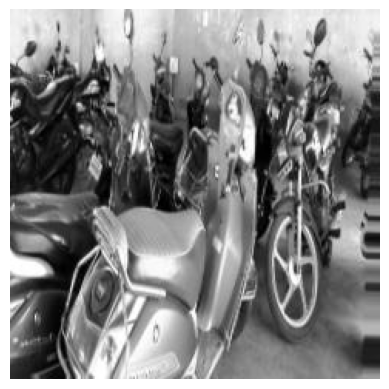

Predicted label:  ['parking']
Nearest neighbors:  (array([[1684, 1764, 1813, 1746, 1841, 1988, 1730, 1718, 2010, 1759]]), array([[   0.        ,  405.49316751,  645.48661484,  692.73838264,
         706.72478082,  763.34947626,  949.98229166,  965.84818963,
         984.7547717 , 1030.38477571]]))


In [8]:
import cv2
import numpy as np
import pickle
import pyflann

# Load the SVM model from the saved file
with open('svm_model.sav', 'rb') as f:
    svm_model = pickle.load(f)

# Set the FAST and FREAK parameters
fast_params = dict(threshold=30, nonmaxSuppression=True)
freak_params = dict()

# Initialize the FAST detector and FREAK extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
freak_extractor = cv2.xfeatures2d.FREAK_create(**freak_params)

# Load the input image and extract FREAK descriptors
input_image = cv2.imread(r'C:\Users\Madhuri-Amit\Desktop\p1\parking\aug_0_1480.jpg')
input_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)

# Display the input image in the notebook
plt.imshow(input_image)
plt.axis('off')
plt.show()
gray_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)
keypoints = fast_detector.detect(gray_image, None)
keypoints, descriptors = freak_extractor.compute(gray_image, keypoints)

# Use the SVM model to predict the class label of the input image
predicted_label = svm_model.predict(np.mean(descriptors, axis=0).reshape(1, -1))

# Load the FREAK descriptors for the dataset into a numpy array
dataset = np.loadtxt('freak.csv', delimiter=',', usecols=range(64))

# Initialize the FLANN index
flann = pyflann.FLANN()

# Build the FLANN index on the dataset
flann.build_index(dataset)

# Find the nearest neighbors of the input image features
nearest_neighbors = flann.nn_index(np.mean(descriptors, axis=0).reshape(1, -1), num_neighbors=10)

# Print the predicted class label and the nearest neighbors
print("Predicted label: ", predicted_label)
print("Nearest neighbors: ", nearest_neighbors)


In [18]:
import cv2
import numpy as np
import pickle
import pyflann

# Load the SVM model from the saved file
with open('svm_model.sav', 'rb') as f:
    svm_model = pickle.load(f)

# Set the FAST and FREAK parameters
fast_params = dict(threshold=30, nonmaxSuppression=True)
freak_params = dict()

# Initialize the FAST detector and FREAK extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
freak_extractor = cv2.xfeatures2d.FREAK_create(**freak_params)

# Load the FREAK descriptors for the dataset into a numpy array
dataset = np.loadtxt('freak.csv', delimiter=',', usecols=range(64))

# Initialize the FLANN index
flann = pyflann.FLANN()
flann.build_index(dataset)

# Set a threshold for unknown frames
unknown_threshold = 0.8

# Define the labels for the dataset
labels = ['class1', 'class2', 'class3', 'class4','class5']

# Initialize the camera
camera = cv2.VideoCapture(0)

while True:
    # Capture a frame from the camera
    ret, frame = camera.read()

    # Convert the frame to grayscale and extract FREAK descriptors
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    keypoints = fast_detector.detect(gray_frame, None)
    keypoints, descriptors = freak_extractor.compute(gray_frame, keypoints)

    # Classify the frame using the SVM model and FLANN index
    if descriptors is not None:
        query_descriptor = np.mean(descriptors, axis=0).reshape(1, -1)
        predicted_label = svm_model.predict(query_descriptor)

        # Find the nearest neighbors of the input image features
        nearest_neighbors, distances = flann.nn_index(query_descriptor, num_neighbors=10)

        # Check if the nearest neighbor is below the unknown threshold
        if np.any(distances <= unknown_threshold):
            predicted_label = labels[nearest_neighbors[distances <= unknown_threshold][0]]
            print("Predicted label: ", predicted_label)
            print("Nearest neighbors: ", nearest_neighbors[distances <= unknown_threshold])
            # Put the predicted label on the camera frame
            cv2.putText(frame, predicted_label, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)
        else:
            print("Unknown")
        
    # Show the frame on the screen
    cv2.imshow("Frame", frame)

    # Wait for a key press
    key = cv2.waitKey(1)

    # Exit the loop if the 'q' key is pressed
    if key == ord('q'):
        break

# Release the camera and close all windows
camera.release()
cv2.destroyAllWindows()


Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown


In [13]:
import cv2
import numpy as np
import pickle
import pyflann

# Load the SVM model from the saved file
with open('svm_model.sav', 'rb') as f:
    svm_model = pickle.load(f)

# Set the FAST and FREAK parameters
fast_params = dict(threshold=30, nonmaxSuppression=True)
freak_params = dict()

# Initialize the FAST detector and FREAK extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
freak_extractor = cv2.xfeatures2d.FREAK_create(**freak_params)

# Load the FREAK descriptors for the dataset into a numpy array
dataset = np.loadtxt('freak.csv', delimiter=',', usecols=range(64))

# Initialize the FLANN index
flann = pyflann.FLANN()
flann.build_index(dataset)

# Set a threshold for unknown frames
unknown_threshold = 0.8

# Initialize the camera
camera = cv2.VideoCapture(0)

while True:
    # Capture a frame from the camera
    ret, frame = camera.read()

    # Convert the frame to grayscale and extract FREAK descriptors
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    keypoints = fast_detector.detect(gray_frame, None)
    keypoints, descriptors = freak_extractor.compute(gray_frame, keypoints)

    # Classify the frame using the SVM model and FLANN index
    if descriptors is not None:
        query_descriptor = np.mean(descriptors, axis=0).reshape(1, -1)
        predicted_label = svm_model.predict(query_descriptor)

        # Find the nearest neighbors of the input image features
        nearest_neighbors, distances = flann.nn_index(query_descriptor, num_neighbors=10)

        # Check if the nearest neighbor is below the unknown threshold
        if np.any(distances <= unknown_threshold):
            predicted_label = dataset_labels[nearest_neighbors[distances <= unknown_threshold][0]]
            print("Predicted label: ", predicted_label)
            print("Nearest neighbors: ", nearest_neighbors[distances <= unknown_threshold])
        else:
            print("Unknown")
        
        
    # Show the frame on the screen
    cv2.imshow("Frame", frame)

    # Wait for a key press
    key = cv2.waitKey(1)

    # Exit the loop if the 'q' key is pressed
    if key == ord('q'):
        break

# Release the camera and close all windows
camera.release()
cv2.destroyAllWindows()


Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown
Unknown


In [11]:
import cv2
import numpy as np
import pickle
import pyflann
import time

# Load the SVM model from the saved file
with open('svm_model.sav', 'rb') as f:
    svm_model = pickle.load(f)

# Set the FAST and FREAK parameters
fast_params = dict(threshold=30, nonmaxSuppression=True)
freak_params = dict()

# Initialize the FAST detector and FREAK extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
freak_extractor = cv2.xfeatures2d.FREAK_create(**freak_params)

# Load the FREAK descriptors for the dataset into a numpy array
dataset = np.loadtxt('freak.csv', delimiter=',', usecols=range(64))

# Initialize the FLANN index
flann = pyflann.FLANN()
# Build the FLANN index on the dataset
flann.build_index(dataset)

# Initialize the webcam
cap = cv2.VideoCapture(0)

while True:
    # Read a frame from the webcam
    ret, frame = cap.read()

    # Convert the frame to grayscale
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect keypoints with the FAST detector
    keypoints = fast_detector.detect(gray_frame, None)

    # Compute FREAK descriptors for the keypoints
    keypoints, descriptors = freak_extractor.compute(gray_frame, keypoints)

    # Use the SVM model to predict the class label of the input image
    predicted_label = svm_model.predict(np.mean(descriptors, axis=0).reshape(1, -1))

    # Find the nearest neighbors of the input image features
    nearest_neighbors = flann.nn_index(np.mean(descriptors, axis=0).reshape(1, -1), num_neighbors=10)

    # Print the predicted class label and the nearest neighbors
    print("Predicted label: ", predicted_label)
    print("Nearest neighbors: ", nearest_neighbors)

    # Display the frame
    cv2.imshow('frame', frame)

    # Wait for a key press and check if the user wants to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

    # Delay for 1 second
    time.sleep(1)

# Release the webcam and close the window
cap.release()
cv2.destroyAllWindows()


Predicted label:  ['playground']
Nearest neighbors:  (array([[ 876, 2110, 1603, 1556, 2322,  390, 1409, 1337, 1179, 2157]]), array([[ 6913.05090509,  7575.52180158,  8738.59271034,  8966.53276489,
         9601.19895833,  9763.80215391,  9858.98624782, 10098.82729229,
        10127.21474772, 10372.55606139]]))
Predicted label:  ['playground']
Nearest neighbors:  (array([[1409, 1330, 2082, 1244, 2157, 1411, 2199, 2102, 1337, 2364]]), array([[12462.9943789 , 13937.72075226, 14186.02114746, 14280.70603287,
        14441.40134521, 14689.38668934, 15164.89486944, 15486.51773725,
        15492.18024509, 16093.10076648]]))
Predicted label:  ['playground']
Nearest neighbors:  (array([[1277, 1556, 1323, 1406, 1387, 1634, 1337, 1188, 1466, 1383]]), array([[10101.01430376, 11203.98866841, 13097.34829369, 13842.55300492,
        14776.84685477, 15234.09162432, 15374.85952319, 15543.65278581,
        15788.88356001, 15830.84600085]]))
Predicted label:  ['playground']
Nearest neighbors:  (array([[12

In [10]:
import cv2
import numpy as np
import pickle
import pyflann

# Load the SVM model from the saved file
with open('svm_model.sav', 'rb') as f:
    svm_model = pickle.load(f)

# Set the FAST and FREAK parameters
fast_params = dict(threshold=30, nonmaxSuppression=True)
freak_params = dict()

# Initialize the FAST detector and FREAK extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
freak_extractor = cv2.xfeatures2d.FREAK_create(**freak_params)

# Load the FREAK descriptors for the dataset into a numpy array
dataset = np.loadtxt('freak.csv', delimiter=',', usecols=range(64))

# Initialize the FLANN index
flann = pyflann.FLANN()
flann.build_index(dataset)

# Initialize the video capture object
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FPS, 30)

# Loop over the frames from the webcam
while True:
    # Capture a frame from the webcam
    ret, frame = cap.read()

    # Convert the frame to grayscale
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect keypoints with the FAST detector
    keypoints = fast_detector.detect(gray_frame, None)

    # Compute FREAK descriptors for the keypoints
    keypoints, descriptors = freak_extractor.compute(gray_frame, keypoints)

    # If there are keypoints detected, use the SVM model and FLANN index to perform place recognition
    if descriptors is not None:
        # Use the SVM model to predict the class label of the input image
        predicted_label = svm_model.predict(np.mean(descriptors, axis=0).reshape(1, -1))

        # Find the nearest neighbors of the input image features
        nearest_neighbors = flann.nn_index(np.mean(descriptors, axis=0).reshape(1, -1), num_neighbors=10)

        # Draw the predicted label and nearest neighbors on the frame
        cv2.putText(frame, "Predicted label: " + str(predicted_label), (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.putText(frame, "Nearest neighbors: " + str(nearest_neighbors[0]), (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # Display the frame
    cv2.imshow('frame', frame)

    # Exit the loop if the 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the video capture object and close all windows
cap.release()
cv2.destroyAllWindows()


In [55]:
import cv2
import numpy as np
import pandas as pd
import pickle

# Load the saved SVM model
with open('svm_model.sav', 'rb') as f:
    svm = pickle.load(f)

# Set the FAST and FREAK parameters
fast_params = dict(threshold=30, nonmaxSuppression=True)
freak_params = dict()

# Initialize the FAST detector and FREAK extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
freak_extractor = cv2.xfeatures2d.FREAK_create(**freak_params)

# Initialize the webcam
cap = cv2.VideoCapture(0)

# Loop over the frames from the webcam
while True:
    # Capture the current frame from the webcam
    ret, frame = cap.read()

    # Convert the frame to grayscale
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect keypoints with the FAST detector
    keypoints = fast_detector.detect(gray_frame, None)

    # Compute FREAK descriptors for the keypoints
    keypoints, descriptors = freak_extractor.compute(gray_frame, keypoints)

    # If there are descriptors, predict the label using the SVM model
    if descriptors is not None:
        # Compute the average of the descriptors
        descriptors_avg = np.mean(descriptors, axis=0)

        # Reshape the descriptors for input into the SVM model
        descriptors_avg = descriptors_avg.reshape(1, -1)

        # Predict the label using the SVM model
        label = svm.predict(descriptors_avg)[0]

        # Print the predicted label to the console
        print("Predicted place: ", label)

        # Put the predicted label on the frame
        cv2.putText(frame, label, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Show the frame
    cv2.imshow('frame', frame)

    # If 'q' is pressed, break out of the loop
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the webcam and close the window
cap.release()
cv2.destroyAllWindows()


Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted place:  playground
Predicted plac

In [58]:
import cv2
import numpy as np
import pickle

import os
import pandas as pd
from sklearn.svm import SVC

# Set the FAST and FREAK parameters
fast_params = dict(threshold=30, nonmaxSuppression=True)
freak_params = dict()

# Initialize the FAST detector and FREAK extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
freak_extractor = cv2.xfeatures2d.FREAK_create(**freak_params)

# Load the trained SVM model
filename = 'svm_model.sav'
svm = pickle.load(open(filename, 'rb'))

# Define the class names
class_names = ['boatclub', 'classroom', 'corridor','parking','playground']

# Initialize the webcam
cap = cv2.VideoCapture(0)

while True:
    # Capture a frame from the webcam
    ret, frame = cap.read()

    # Convert the frame to grayscale
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect keypoints with the FAST detector
    keypoints = fast_detector.detect(gray_frame, None)

    # Compute FREAK descriptors for the keypoints
    keypoints, descriptors = freak_extractor.compute(gray_frame, keypoints)

    # If descriptors were computed, predict the class of the image
    if descriptors is not None:
        # Compute the mean descriptor
        descriptor = np.mean(descriptors, axis=0)
        
        # Predict the class using the SVM model
        prediction = svm.predict([descriptor])[0]
        
        # Print the predicted class name
        if prediction in class_names:
            print(prediction)
        else:
            print("unknown")

    # Display the frame
    cv2.imshow('frame', frame)

    # If 'q' is pressed, break out of the loop
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the webcam and close the window
cap.release()
cv2.destroyAllWindows()


playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground
playground

In [60]:
import cv2
import numpy as np
import pickle

# Load the trained SVM model
filename = 'svm_model.sav'
svm = pickle.load(open(filename, 'rb'))

# Set the FAST and FREAK parameters
fast_params = dict(threshold=30, nonmaxSuppression=True)
freak_params = dict()

# Initialize the FAST detector and FREAK extractor
fast_detector = cv2.FastFeatureDetector_create(**fast_params)
freak_extractor = cv2.xfeatures2d.FREAK_create(**freak_params)

# Load the class names
class_names = ['boatclub', 'classroom', 'corridor','parking','playground']

# Initialize the camera
cap = cv2.VideoCapture(0)

while True:
    # Capture a frame from the camera
    ret, frame = cap.read()

    # Convert the frame to grayscale
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect keypoints with the FAST detector
    keypoints = fast_detector.detect(gray_frame, None)

    # Compute FREAK descriptors for the keypoints
    keypoints, descriptors = freak_extractor.compute(gray_frame, keypoints)

    # Check if any keypoints were detected
    if descriptors is not None:
        # Compute the descriptor for the current frame
        descriptor = np.mean(descriptors, axis=0)

        # Predict the class of the current frame
        prediction = svm.predict([descriptor])

        # Get the name of the predicted class
        try:
            class_name = class_names[int(prediction)]
        except:
            class_name = "unknown"

        # Draw the predicted class label on the camera frame
        cv2.putText(frame, class_name, (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    # Display the camera frame
    cv2.imshow('frame', frame)

    # Check for the 'q' key to quit the program
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the camera and close all windows
cap.release()
cv2.destroyAllWindows()


In [ ]:
import cv2

# Load the input image
img = cv2.imread(r'C:\Users\Madhuri-Amit\Desktop\preprocessed\boatclub\4.jpg')

# Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Initialize the STAR detector
star = cv2.xfeatures2d.StarDetector_create()

# Detect keypoints in the image using the STAR detector
keypoints = star.detect(gray, None)

# Draw the detected keypoints on the image
img_keypoints = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0))

# Show the original image and the image with detected keypoints
cv2.imshow('Input Image', img)
cv2.imshow('Detected Keypoints', img_keypoints)
cv2.waitKey(0)
cv2.destroyAllWindows()


# selection of detector and descriptor

# fast

Number of keypoints detected: 316


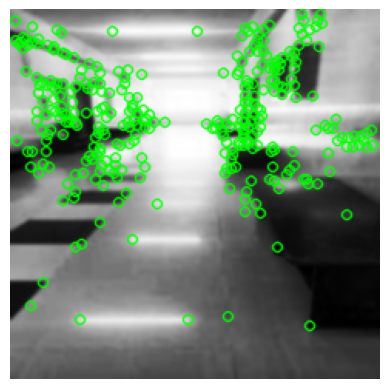

In [6]:
import cv2
import matplotlib.pyplot as plt

# Load the input image
img = cv2.imread(r'C:\Users\Madhuri-Amit\Desktop\preprocessed\corridor\5.jpg')

# Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Create a FAST object with default parameters
fast = cv2.FastFeatureDetector_create()

# Detect keypoints using FAST
keypoints = fast.detect(gray, None)

# Draw keypoints on the image
img_with_keypoints = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0))
print(f"Number of keypoints detected: {len(keypoints)}")

# Display the image with keypoints in a Jupyter notebook
plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


# star

Number of keypoints detected: 26


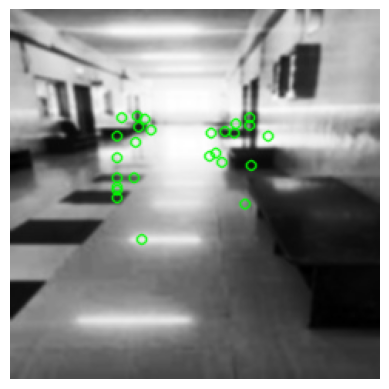

In [7]:
import cv2
import matplotlib.pyplot as plt

# Load the input image
img = cv2.imread(r'C:\Users\Madhuri-Amit\Desktop\preprocessed\corridor\5.jpg')

# Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Create a STAR object with default parameters
star = cv2.xfeatures2d.StarDetector_create()

# Detect keypoints using STAR
keypoints = star.detect(gray, None)

# Draw keypoints on the image
img_with_keypoints = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0))
print(f"Number of keypoints detected: {len(keypoints)}")

# Display the image with keypoints in a Jupyter notebook
plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


# star+freak

Number of keypoints detected: 25


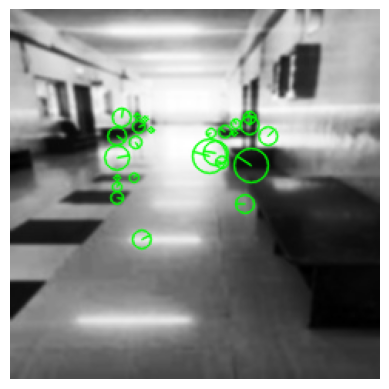

In [11]:
import cv2
import matplotlib.pyplot as plt

# Load the input image
img = cv2.imread(r'C:\Users\Madhuri-Amit\Desktop\preprocessed\corridor\5.jpg')

# Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Create a STAR object with default parameters
star = cv2.xfeatures2d.StarDetector_create()

# Detect keypoints using STAR
keypoints = star.detect(gray, None)

# Create a FREAK object with default parameters
freak = cv2.xfeatures2d.FREAK_create()

# Compute FREAK descriptors for each keypoint
keypoints, descriptors = freak.compute(gray, keypoints)

# Draw keypoints and orientation lines on the image
img_with_keypoints = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
print(f"Number of keypoints detected: {len(keypoints)}")
# Display the image with keypoints and orientation lines in a Jupyter notebook
plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


# fast+freak

Number of keypoints detected: 245


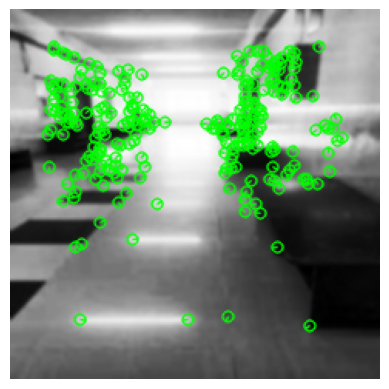

In [12]:
import cv2
import matplotlib.pyplot as plt

# Load the input image
img = cv2.imread(r'C:\Users\Madhuri-Amit\Desktop\preprocessed\corridor\5.jpg')

# Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Create a FAST object with default parameters
fast = cv2.FastFeatureDetector_create()

# Detect keypoints using FAST
keypoints = fast.detect(gray, None)

# Create a FREAK object with default parameters
freak = cv2.xfeatures2d.FREAK_create()

# Compute FREAK descriptors for each keypoint
keypoints, descriptors = freak.compute(gray, keypoints)

# Draw keypoints and orientation lines on the image
img_with_keypoints = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
print(f"Number of keypoints detected: {len(keypoints)}")
# Display the image with keypoints and orientation lines in a Jupyter notebook
plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


# star+brief

Number of keypoints detected: 26


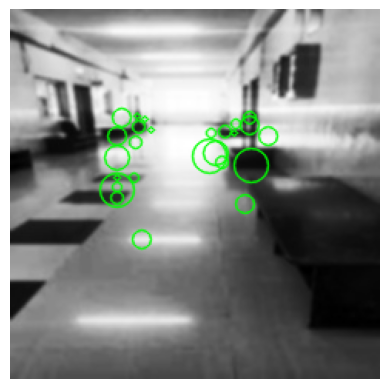

In [17]:
import cv2
import matplotlib.pyplot as plt

# Load the input image
img = cv2.imread(r'C:\Users\Madhuri-Amit\Desktop\preprocessed\corridor\5.jpg')

# Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Create a STAR detector object with default parameters
star = cv2.xfeatures2d.StarDetector_create()

# Detect keypoints using the STAR detector
keypoints = star.detect(gray, None)

# Create a BRIEF object with default parameters
brief = cv2.xfeatures2d.BriefDescriptorExtractor_create()

# Compute BRIEF descriptors for each keypoint
keypoints, descriptors = brief.compute(gray, keypoints)

# Draw keypoints and orientation lines on the image
img_with_keypoints = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
print(f"Number of keypoints detected: {len(keypoints)}")
# Display the image with keypoints and orientation lines in a Jupyter notebook
plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


# fast+brief

Number of keypoints detected: 230


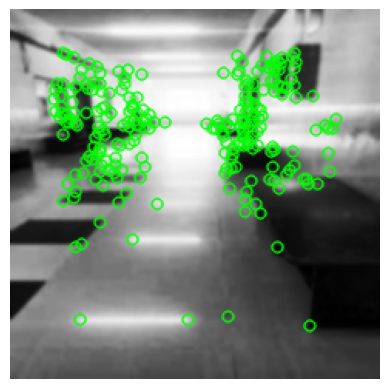

In [21]:
import cv2
import matplotlib.pyplot as plt

# Load the input image
img = cv2.imread(r'C:\Users\Madhuri-Amit\Desktop\preprocessed\corridor\5.jpg')

# Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Create a FAST detector object with default parameters
fast = cv2.FastFeatureDetector_create()

# Detect keypoints using the FAST detector
keypoints = fast.detect(gray, None)

# Create a BRIEF object with default parameters
brief = cv2.xfeatures2d.BriefDescriptorExtractor_create()

# Compute BRIEF descriptors for each keypoint
keypoints, descriptors = brief.compute(gray, keypoints)

# Draw keypoints and orientation lines on the image
img_with_keypoints = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
print(f"Number of keypoints detected: {len(keypoints)}")
# Display the image with keypoints and orientation lines in a Jupyter notebook
plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


# only orb

Number of keypoints detected: 386


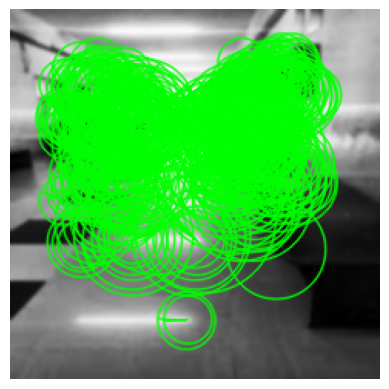

In [23]:
import cv2
import matplotlib.pyplot as plt

# Load the input image
img = cv2.imread(r'C:\Users\Madhuri-Amit\Desktop\preprocessed\corridor\5.jpg')

# Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Create an ORB detector object with default parameters
orb = cv2.ORB_create()

# Detect keypoints using the ORB detector
keypoints = orb.detect(gray, None)

# Compute descriptors for each keypoint
keypoints, descriptors = orb.compute(gray, keypoints)

# Draw keypoints on the image
img_with_keypoints = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
print(f"Number of keypoints detected: {len(keypoints)}")
# Display the image with keypoints in a Jupyter notebook
plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


# brisk

Number of keypoints detected: 137


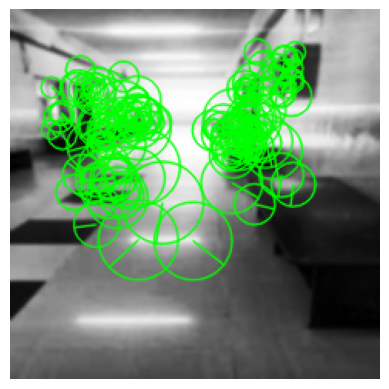

In [24]:
import cv2
import matplotlib.pyplot as plt

# Load the input image
img = cv2.imread(r'C:\Users\Madhuri-Amit\Desktop\preprocessed\corridor\5.jpg')

# Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Create a BRISK detector object with default parameters
brisk = cv2.BRISK_create()

# Detect keypoints using the BRISK detector
keypoints = brisk.detect(gray, None)

# Compute descriptors for each keypoint
keypoints, descriptors = brisk.compute(gray, keypoints)

# Draw keypoints on the image
img_with_keypoints = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
print(f"Number of keypoints detected: {len(keypoints)}")
# Display the image with keypoints in a Jupyter notebook
plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


# sift

Number of keypoints detected: 188


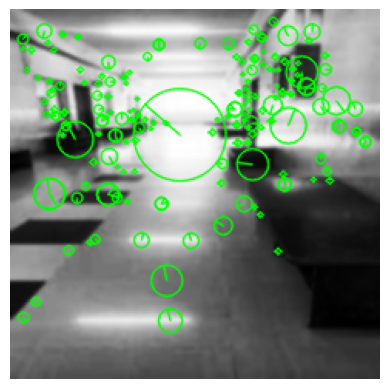

In [27]:
import cv2
import matplotlib.pyplot as plt

# Load the input image
img = cv2.imread(r'C:\Users\Madhuri-Amit\Desktop\preprocessed\corridor\5.jpg')

# Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Create a SIFT detector object with default parameters
sift = cv2.xfeatures2d.SIFT_create()

# Detect keypoints using the SIFT detector
keypoints = sift.detect(gray, None)

# Compute descriptors for each keypoint
keypoints, descriptors = sift.compute(gray, keypoints)


# Draw keypoints on the image
img_with_keypoints = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
print(f"Number of keypoints detected: {len(keypoints)}")
# Display the image with keypoints in a Jupyter notebook
plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
